In [2]:
!pip -q install shap python-docx openpyxl


In [4]:
from google.colab import files
uploaded = files.upload()


Saving all_processes_from_pdf.csv to all_processes_from_pdf (1).csv


In [5]:
import os
import json
import math
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from docx import Document
from docx.shared import Inches

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 140

# ========= USER SETTINGS =========
CSV_PATH = "all_processes_from_pdf.csv"   # uploaded file name
SELECTED_PROCESS = "Gold Cyanidation"     # change this to any process in your CSV
MAIN_TARGET = "recoveryRate"              # main target for SHAP + response surface
OTHER_TARGETS = ["efficiency", "co2Emissions"]  # extra targets for model comparison
OUTDIR = "report_outputs"
os.makedirs(OUTDIR, exist_ok=True)

# ========= LOAD DATA =========
df = pd.read_csv(CSV_PATH)

required_cols = [
    "processName",
    "condition_1_name", "condition_1_value",
    "condition_2_name", "condition_2_value",
    "condition_3_name", "condition_3_value",
    "condition_4_name", "condition_4_value",
    "recoveryRate", "efficiency",
    "wasteGenerated", "waterUsage", "energyConsumption", "co2Emissions"
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# keep only selected process
proc = df[df["processName"] == SELECTED_PROCESS].copy()
if proc.empty:
    raise ValueError(f"No rows found for process: {SELECTED_PROCESS}")

# numeric cleanup
FEATURES = [
    "condition_1_value",
    "condition_2_value",
    "condition_3_value",
    "condition_4_value",
]
TARGETS = [MAIN_TARGET] + [t for t in OTHER_TARGETS if t != MAIN_TARGET]

for c in FEATURES + TARGETS + ["wasteGenerated", "waterUsage", "energyConsumption", "co2Emissions"]:
    proc[c] = pd.to_numeric(proc[c], errors="coerce")

proc = proc.dropna(subset=FEATURES + TARGETS).reset_index(drop=True)

feature_labels = [
    str(proc["condition_1_name"].iloc[0]),
    str(proc["condition_2_name"].iloc[0]),
    str(proc["condition_3_name"].iloc[0]),
    str(proc["condition_4_name"].iloc[0]),
]

X = proc[FEATURES].copy()
X.columns = feature_labels

print("Selected process:", SELECTED_PROCESS)
print("Rows:", len(proc))
print("Feature labels:", feature_labels)
print(proc.head())


Selected process: Gold Cyanidation
Rows: 20
Feature labels: ['oreGrade (g/t Au)', 'cyanideConc (mol/L)', 'pH', 'leachTime (hr)']
        processName   condition_1_name  condition_1_value  \
0  Gold Cyanidation  oreGrade (g/t Au)                3.5   
1  Gold Cyanidation  oreGrade (g/t Au)                5.0   
2  Gold Cyanidation  oreGrade (g/t Au)                2.5   
3  Gold Cyanidation  oreGrade (g/t Au)                4.2   
4  Gold Cyanidation  oreGrade (g/t Au)                1.8   

      condition_2_name  condition_2_value condition_3_name  condition_3_value  \
0  cyanideConc (mol/L)              0.050               pH               10.5   
1  cyanideConc (mol/L)              0.045               pH               11.0   
2  cyanideConc (mol/L)              0.060               pH               10.0   
3  cyanideConc (mol/L)              0.048               pH               10.8   
4  cyanideConc (mol/L)              0.070               pH                9.5   

  condition_4_nam

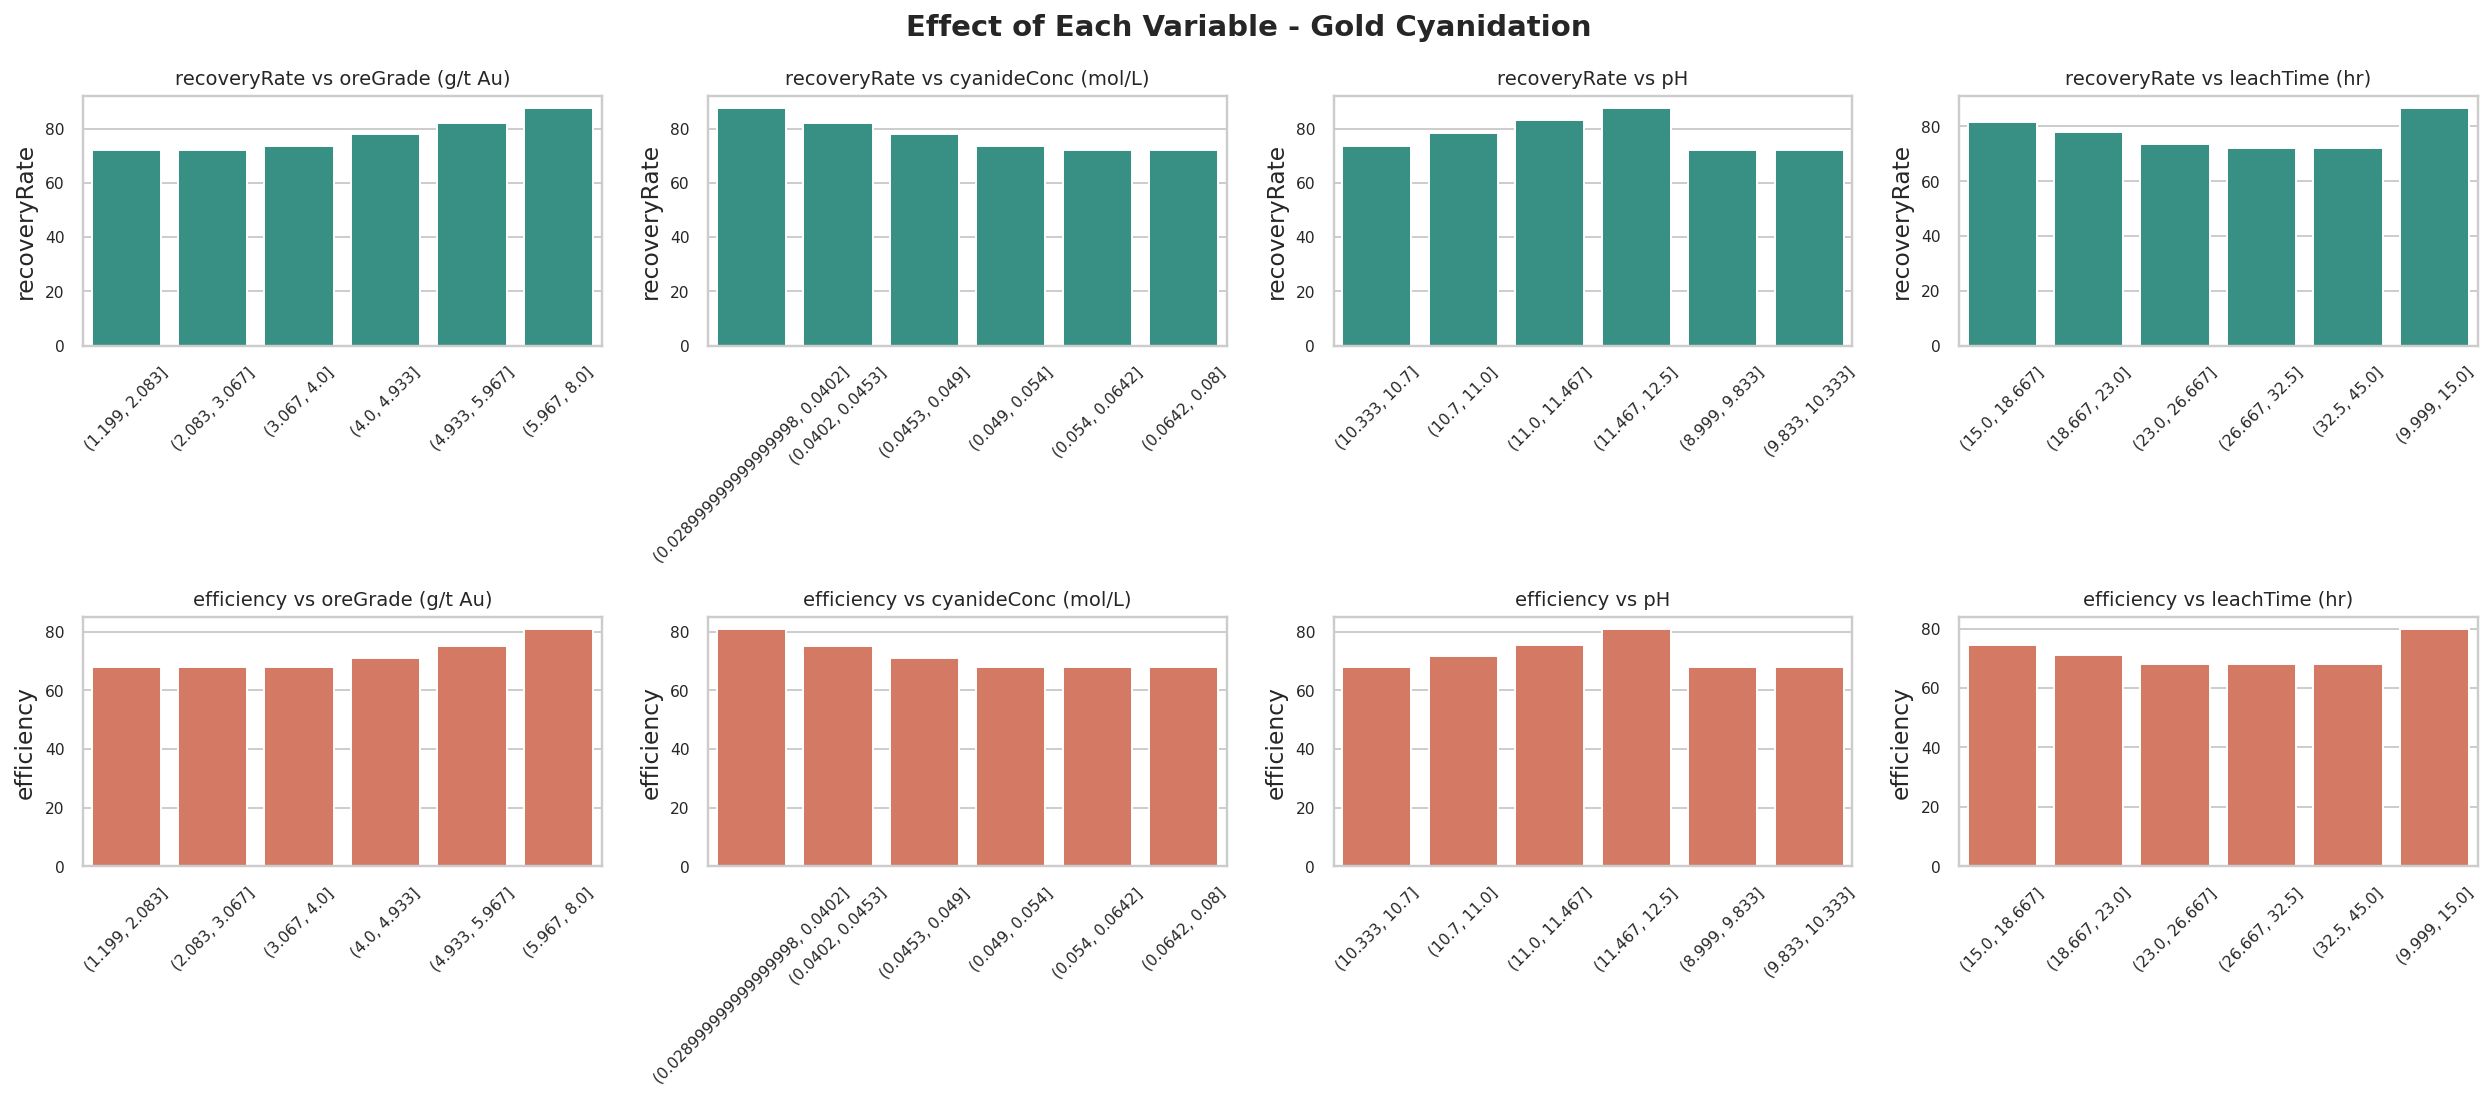

In [7]:
def make_binned_labels(series, max_bins=6):
    unique_vals = np.sort(series.dropna().unique())
    if len(unique_vals) <= max_bins:
        return series.astype(str)
    bins = pd.qcut(series, q=max_bins, duplicates="drop")
    return bins.astype(str)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
targets_for_effect = ["recoveryRate", "efficiency"]

for j, target in enumerate(targets_for_effect):
    for i, feat in enumerate(X.columns):
        ax = axes[j, i]
        tmp = proc[[FEATURES[i], target]].copy()
        tmp["bin"] = make_binned_labels(tmp[FEATURES[i]])
        grp = tmp.groupby("bin", observed=False)[target].mean().reset_index()

        sns.barplot(data=grp, x="bin", y=target, ax=ax, color="#2a9d8f" if j == 0 else "#e76f51")
        ax.set_title(f"{target} vs {feat}", fontsize=10)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=45, labelsize=8)
        ax.tick_params(axis="y", labelsize=8)

plt.suptitle(f"Effect of Each Variable - {SELECTED_PROCESS}", fontsize=15, weight="bold")
plt.tight_layout()
f1 = os.path.join(OUTDIR, "figure_1_variable_effects.png")
plt.savefig(f1, bbox_inches="tight")
plt.show()


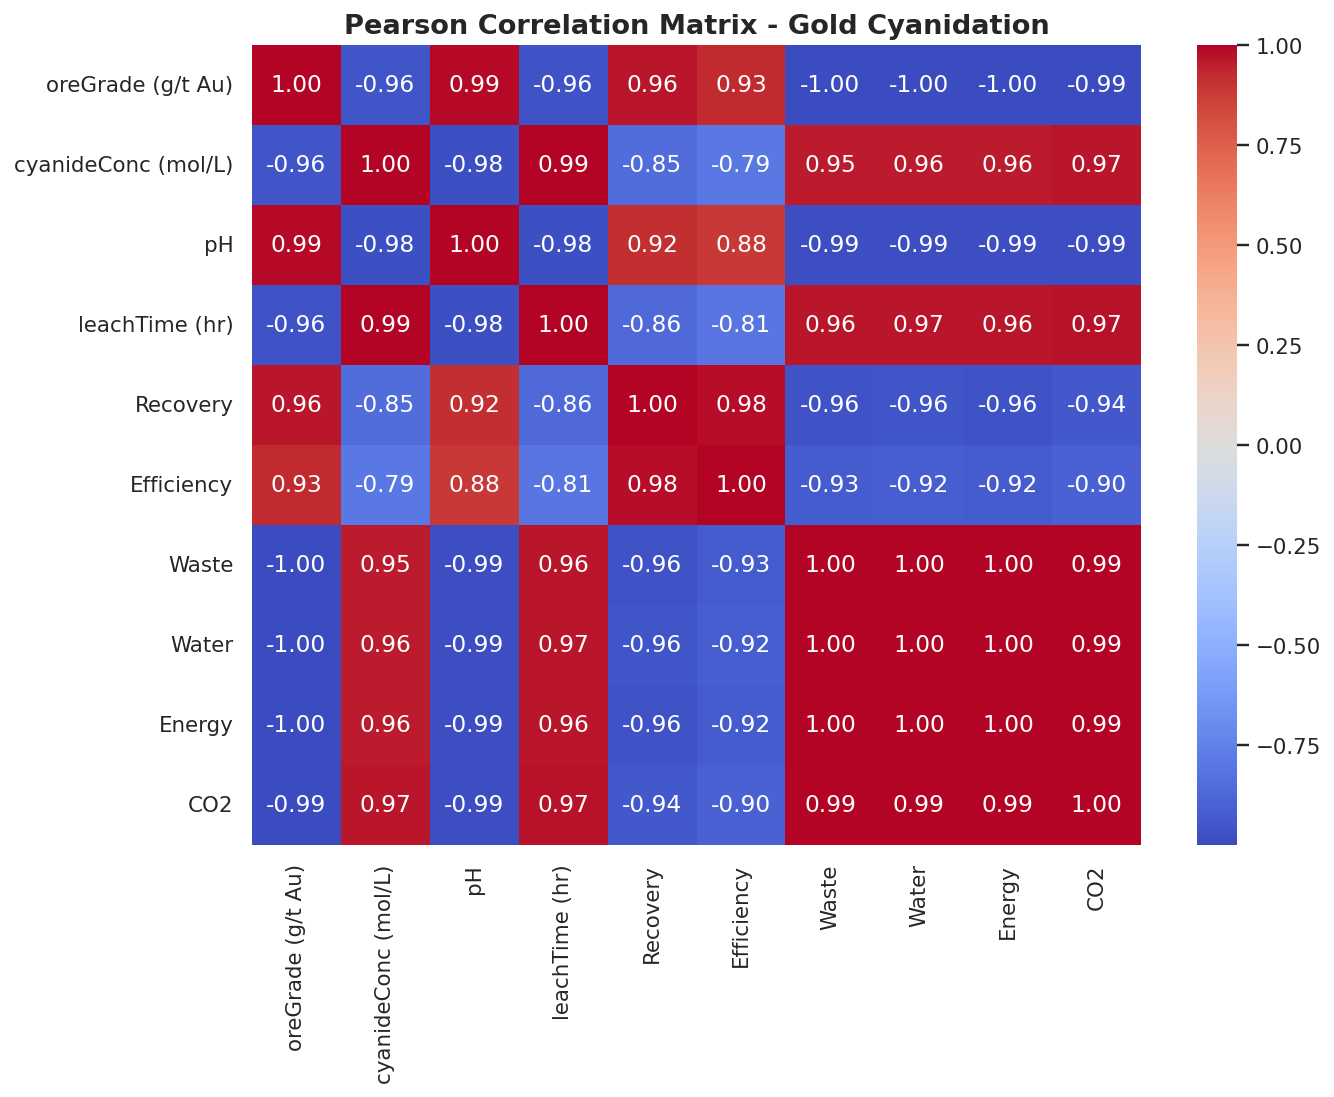

In [9]:
corr_cols = FEATURES + ["recoveryRate", "efficiency", "wasteGenerated", "waterUsage", "energyConsumption", "co2Emissions"]
corr_df = proc[corr_cols].copy()
corr_df.columns = feature_labels + ["Recovery", "Efficiency", "Waste", "Water", "Energy", "CO2"]

plt.figure(figsize=(10, 8))
corr = corr_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title(f"Pearson Correlation Matrix - {SELECTED_PROCESS}", fontsize=14, weight="bold")
f2 = os.path.join(OUTDIR, "figure_2_correlation_heatmap.png")
plt.tight_layout()
plt.savefig(f2, bbox_inches="tight")
plt.show()


In [11]:
models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        min_samples_leaf=1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42,
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3
    ),
    "SVR (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(C=20.0, gamma="scale", epsilon=0.2))
    ])
}

loo = LeaveOneOut()
results = []
pred_store = {}

for target in TARGETS:
    y = proc[target].values
    pred_store[target] = {}

    for model_name, model in models.items():
        y_pred = cross_val_predict(model, X, y, cv=loo)
        r2 = r2_score(y, y_pred)
        mae = mean_absolute_error(y, y_pred)

        results.append({
            "Target": target,
            "Model": model_name,
            "LOOCV_R2": r2,
            "LOOCV_MAE": mae
        })

        pred_store[target][model_name] = {
            "y_true": y,
            "y_pred": y_pred
        }

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(["Target", "LOOCV_R2"], ascending=[True, False]).reset_index(drop=True)
results_df


,Target,Model,LOOCV_R2,LOOCV_MAE
0,co2Emissions,Gradient Boosting,0.952021,69.947065
1,co2Emissions,Random Forest,0.951997,66.601167
2,co2Emissions,SVR (RBF),0.145817,296.101931
3,efficiency,Gradient Boosting,0.933395,0.721799
4,efficiency,Random Forest,0.926399,0.676850
5,efficiency,SVR (RBF),0.919339,0.715240
6,recoveryRate,Gradient Boosting,0.967699,0.637476
7,recoveryRate,Random Forest,0.963302,0.673467
8,recoveryRate,SVR (RBF),0.955794,0.785910


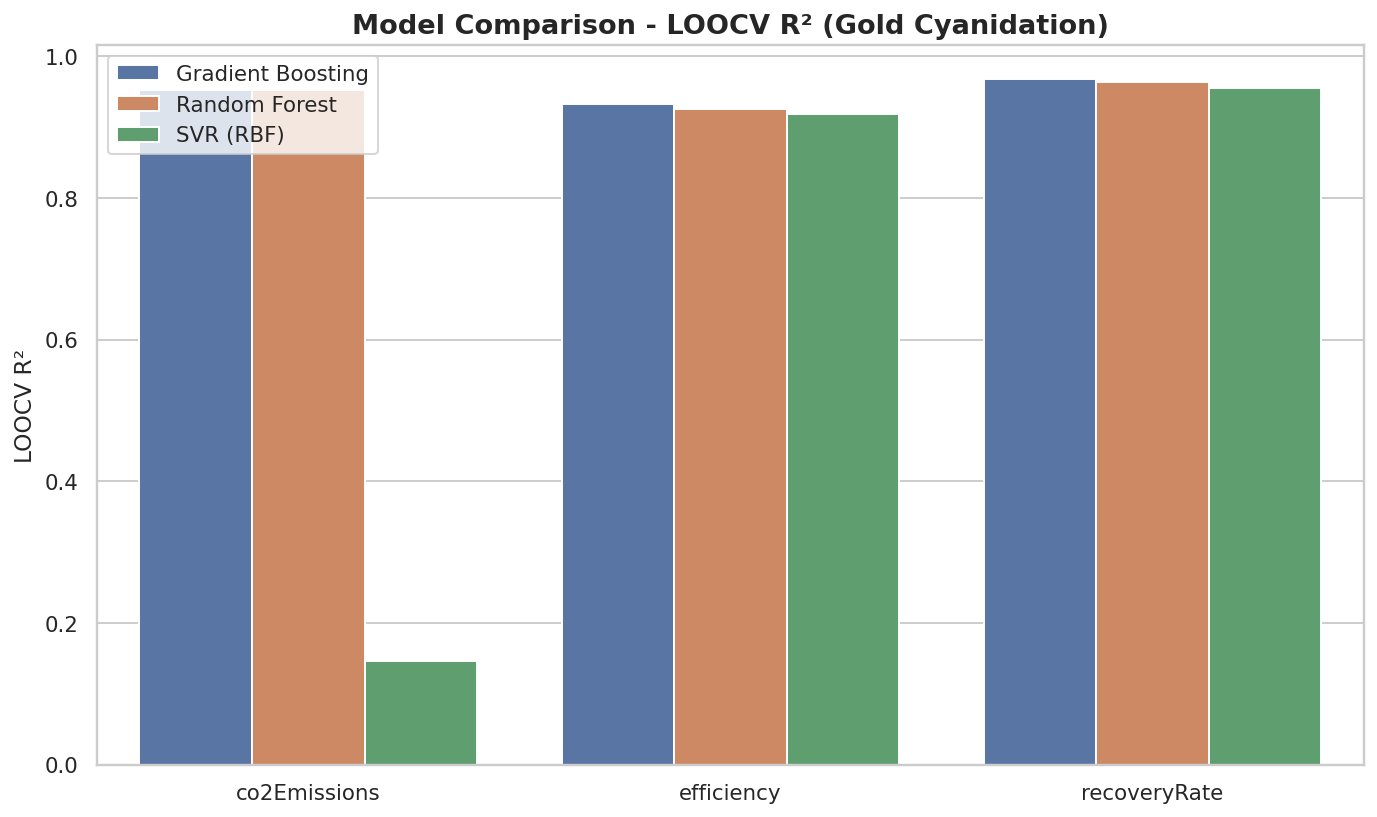

         Target              Model  LOOCV_R2   LOOCV_MAE
0  co2Emissions  Gradient Boosting  0.952021   69.947065
1  co2Emissions      Random Forest  0.951997   66.601167
2  co2Emissions          SVR (RBF)  0.145817  296.101931
3    efficiency  Gradient Boosting  0.933395    0.721799
4    efficiency      Random Forest  0.926399    0.676850
5    efficiency          SVR (RBF)  0.919339    0.715240
6  recoveryRate  Gradient Boosting  0.967699    0.637476
7  recoveryRate      Random Forest  0.963302    0.673467
8  recoveryRate          SVR (RBF)  0.955794    0.785910


In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Target", y="LOOCV_R2", hue="Model")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title(f"Model Comparison - LOOCV R² ({SELECTED_PROCESS})", fontsize=14, weight="bold")
plt.ylabel("LOOCV R²")
plt.xlabel("")
plt.legend(title="")
f3 = os.path.join(OUTDIR, "figure_3_model_comparison.png")
plt.tight_layout()
plt.savefig(f3, bbox_inches="tight")
plt.show()

table_path = os.path.join(OUTDIR, "table_model_comparison.csv")
results_df.to_csv(table_path, index=False)
print(results_df)


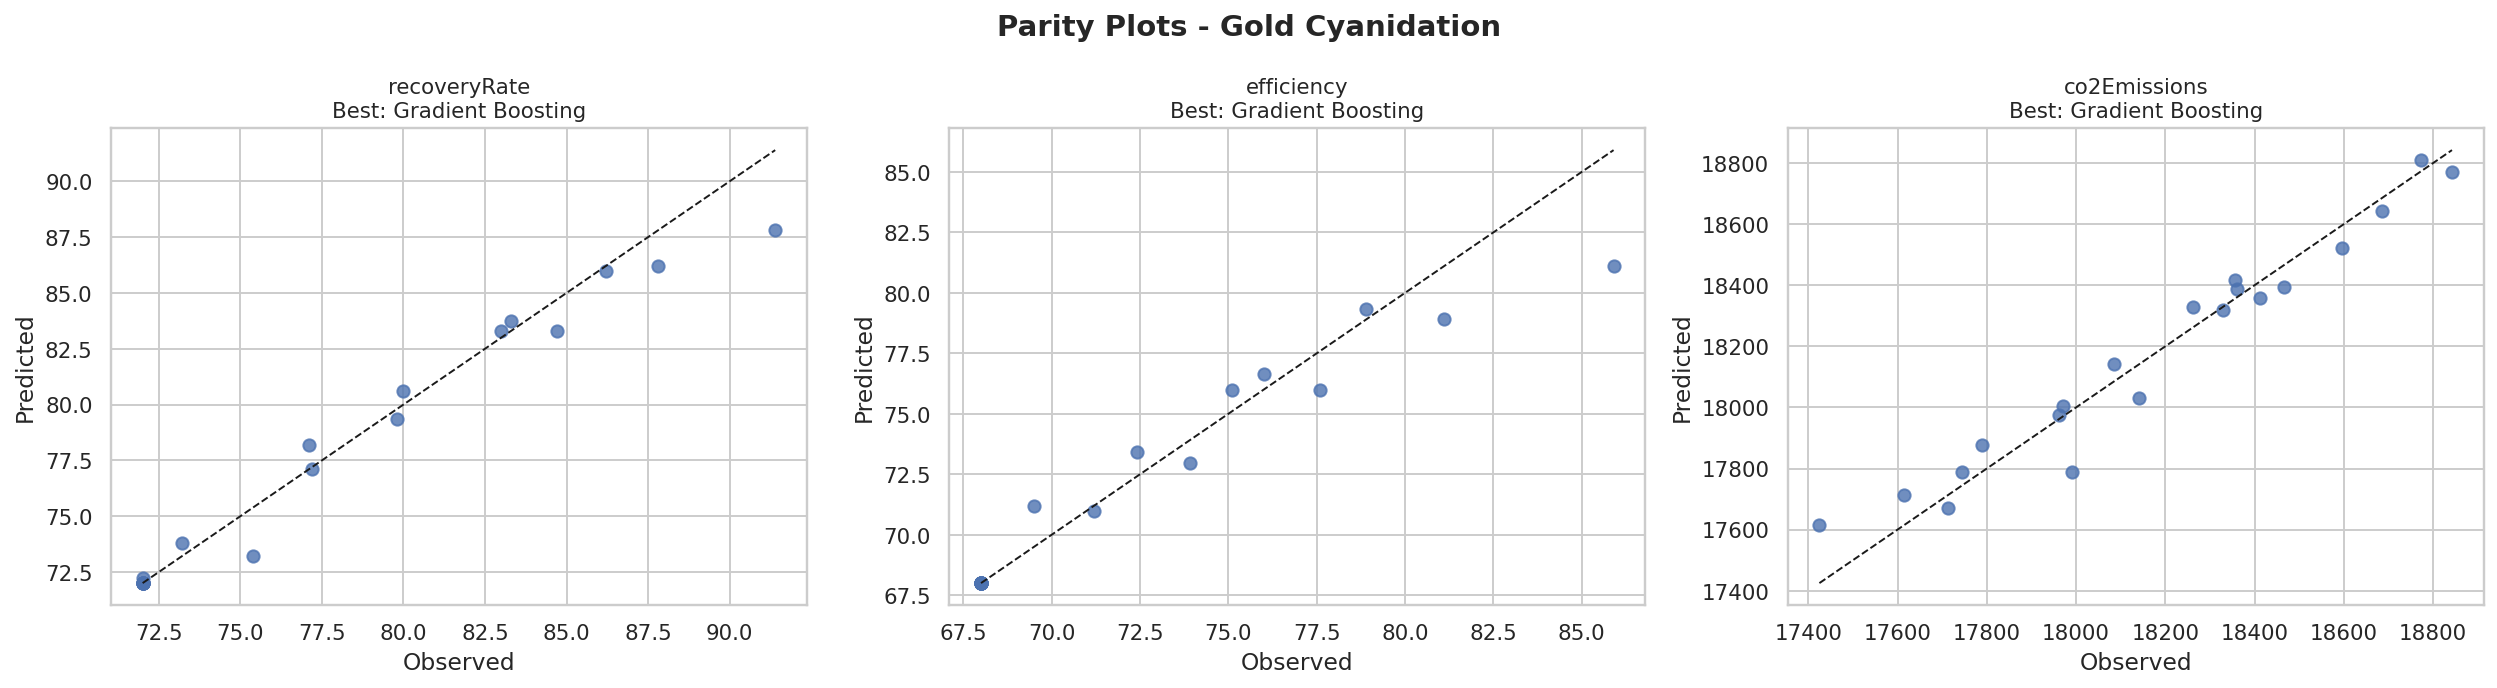

In [15]:
best_models = {}
for target in TARGETS:
    sub = results_df[results_df["Target"] == target].sort_values("LOOCV_R2", ascending=False)
    best_models[target] = sub.iloc[0]["Model"]

fig, axes = plt.subplots(1, len(TARGETS), figsize=(6 * len(TARGETS), 5))
if len(TARGETS) == 1:
    axes = [axes]

for ax, target in zip(axes, TARGETS):
    best_model_name = best_models[target]
    y_true = pred_store[target][best_model_name]["y_true"]
    y_pred = pred_store[target][best_model_name]["y_pred"]

    ax.scatter(y_true, y_pred, s=40, alpha=0.8)
    mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], "k--", lw=1)
    ax.set_title(f"{target}\nBest: {best_model_name}", fontsize=11)
    ax.set_xlabel("Observed")
    ax.set_ylabel("Predicted")

plt.suptitle(f"Parity Plots - {SELECTED_PROCESS}", fontsize=15, weight="bold")
plt.tight_layout()
f4 = os.path.join(OUTDIR, "figure_4_parity_plots.png")
plt.savefig(f4, bbox_inches="tight")
plt.show()


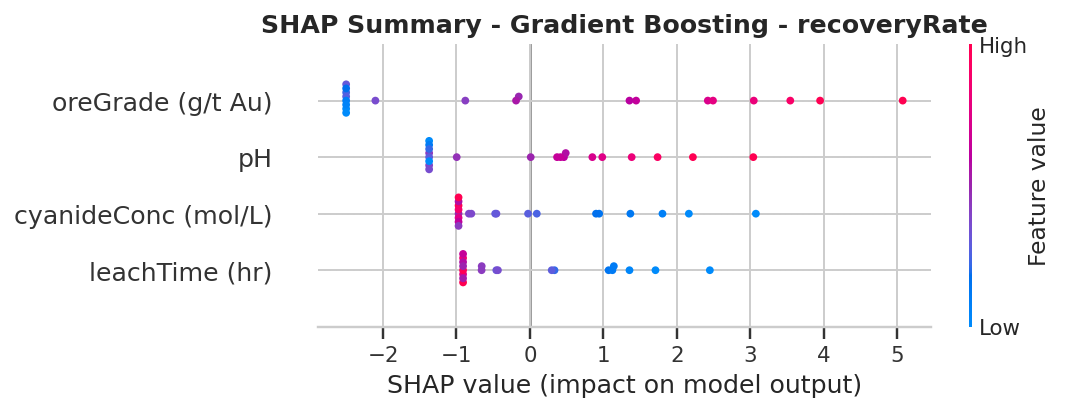

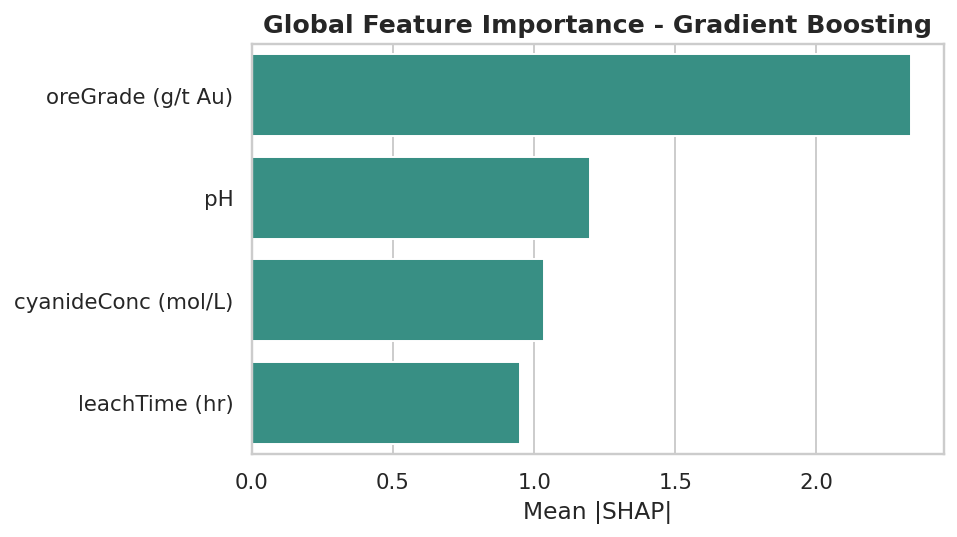

,Feature,MeanAbsSHAP
0,oreGrade (g/t Au),2.333859
2,pH,1.197145
1,cyanideConc (mol/L),1.035176
3,leachTime (hr),0.948590


In [17]:
tree_candidates = ["Random Forest", "Gradient Boosting"]
tree_scores = results_df[(results_df["Target"] == MAIN_TARGET) & (results_df["Model"].isin(tree_candidates))]
best_tree_name = tree_scores.sort_values("LOOCV_R2", ascending=False).iloc[0]["Model"]

best_tree_model = models[best_tree_name]
best_tree_model.fit(X, proc[MAIN_TARGET])

explainer = shap.Explainer(best_tree_model, X)
shap_values = explainer(X)

# beeswarm
plt.figure()
shap.plots.beeswarm(shap_values, show=False, max_display=len(X.columns))
plt.title(f"SHAP Summary - {best_tree_name} - {MAIN_TARGET}", fontsize=13, weight="bold")
f5a = os.path.join(OUTDIR, "figure_5a_shap_summary.png")
plt.tight_layout()
plt.savefig(f5a, bbox_inches="tight")
plt.show()

# mean absolute SHAP bar
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
imp_df = pd.DataFrame({
    "Feature": X.columns,
    "MeanAbsSHAP": mean_abs_shap
}).sort_values("MeanAbsSHAP", ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(data=imp_df, x="MeanAbsSHAP", y="Feature", color="#2a9d8f")
plt.title(f"Global Feature Importance - {best_tree_name}", fontsize=13, weight="bold")
plt.xlabel("Mean |SHAP|")
plt.ylabel("")
f5b = os.path.join(OUTDIR, "figure_5b_shap_bar.png")
plt.tight_layout()
plt.savefig(f5b, bbox_inches="tight")
plt.show()

imp_df



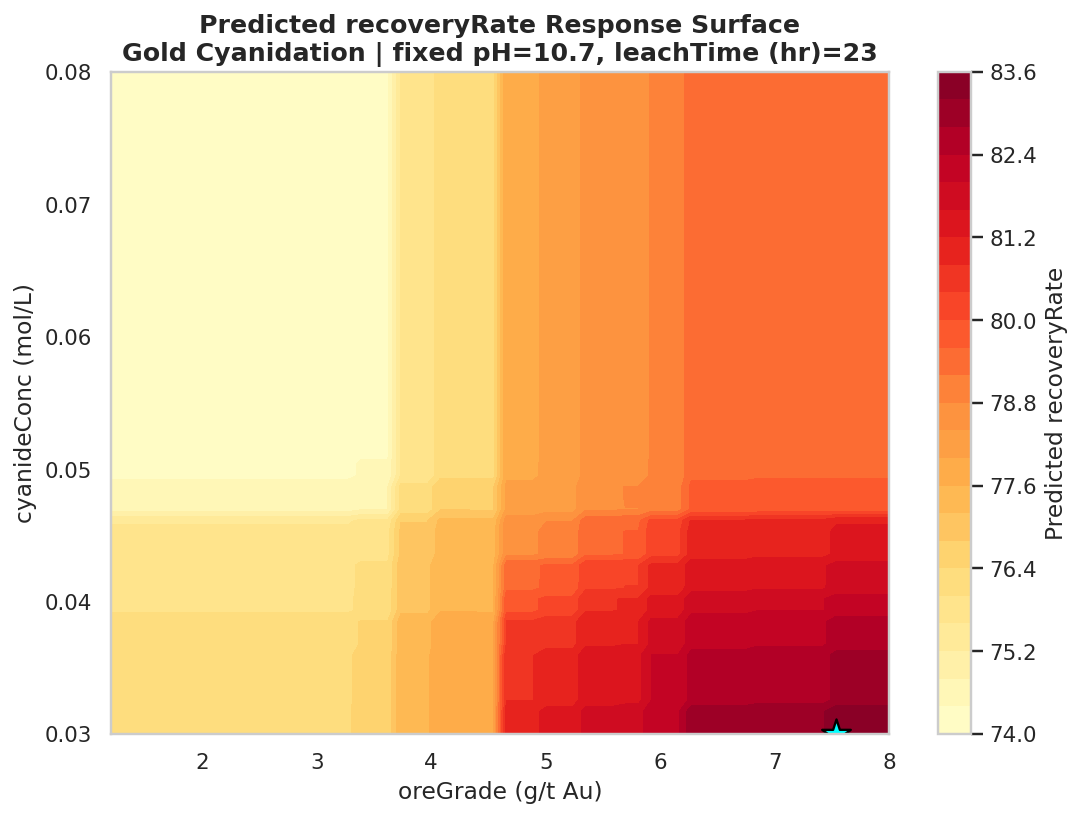

Predicted optimum:
{'oreGrade (g/t Au)': np.float64(7.538983050847458), 'cyanideConc (mol/L)': np.float64(0.03), 'recoveryRate': np.float64(83.46141035007713)}


In [19]:
# choose first two process variables for surface
x1_name = X.columns[0]
x2_name = X.columns[1]

x1_vals = np.linspace(X[x1_name].min(), X[x1_name].max(), 60)
x2_vals = np.linspace(X[x2_name].min(), X[x2_name].max(), 60)
xx, yy = np.meshgrid(x1_vals, x2_vals)

fixed_3 = X[X.columns[2]].median()
fixed_4 = X[X.columns[3]].median()

grid = pd.DataFrame({
    x1_name: xx.ravel(),
    x2_name: yy.ravel(),
    X.columns[2]: fixed_3,
    X.columns[3]: fixed_4
})

zz = best_tree_model.predict(grid).reshape(xx.shape)

best_idx = np.unravel_index(np.argmax(zz), zz.shape)
best_x = xx[best_idx]
best_y = yy[best_idx]
best_z = zz[best_idx]

plt.figure(figsize=(8, 6))
contour = plt.contourf(xx, yy, zz, levels=25, cmap="YlOrRd")
plt.colorbar(contour, label=f"Predicted {MAIN_TARGET}")
plt.scatter(best_x, best_y, marker="*", s=240, color="cyan", edgecolor="black", linewidth=1.2)
plt.xlabel(x1_name)
plt.ylabel(x2_name)
plt.title(
    f"Predicted {MAIN_TARGET} Response Surface\n"
    f"{SELECTED_PROCESS} | fixed {X.columns[2]}={fixed_3:.3g}, {X.columns[3]}={fixed_4:.3g}",
    fontsize=13,
    weight="bold"
)
f6 = os.path.join(OUTDIR, "figure_6_response_surface.png")
plt.tight_layout()
plt.savefig(f6, bbox_inches="tight")
plt.show()

print("Predicted optimum:")
print({x1_name: best_x, x2_name: best_y, MAIN_TARGET: best_z})


In [21]:
doc = Document()
doc.add_heading(f'ML Report - {SELECTED_PROCESS}', 0)

doc.add_paragraph(
    f'This report was automatically generated for the process "{SELECTED_PROCESS}" '
    f'using the dataset "{CSV_PATH}".'
)

doc.add_heading('1. Dataset Summary', level=1)
doc.add_paragraph(f'Number of samples used: {len(proc)}')
doc.add_paragraph('Process variables used:')
for lbl in feature_labels:
    doc.add_paragraph(f'- {lbl}', style='List Bullet')

doc.add_heading('2. Variable Effect Analysis', level=1)
doc.add_paragraph('Figure 1 shows how recovery rate and efficiency vary with each process variable.')
doc.add_picture(f1, width=Inches(6.5))

doc.add_heading('3. Correlation Analysis', level=1)
doc.add_paragraph('Figure 2 shows the Pearson correlation matrix between process variables and process/environmental metrics.')
doc.add_picture(f2, width=Inches(6.5))

doc.add_heading('4. Model Performance', level=1)
doc.add_paragraph('Figure 3 compares the LOOCV R² values of the candidate models across the selected targets.')
doc.add_picture(f3, width=Inches(6.3))

doc.add_paragraph('Table: LOOCV model comparison results')
table = doc.add_table(rows=1, cols=4)
hdr = table.rows[0].cells
hdr[0].text = 'Target'
hdr[1].text = 'Model'
hdr[2].text = 'LOOCV R²'
hdr[3].text = 'LOOCV MAE'

for _, row in results_df.iterrows():
    cells = table.add_row().cells
    cells[0].text = str(row['Target'])
    cells[1].text = str(row['Model'])
    cells[2].text = f"{row['LOOCV_R2']:.3f}"
    cells[3].text = f"{row['LOOCV_MAE']:.3f}"

doc.add_heading('5. Parity Plots', level=1)
doc.add_paragraph('Figure 4 compares observed vs predicted values for the best model on each target.')
doc.add_picture(f4, width=Inches(6.5))

doc.add_heading('6. SHAP Feature Importance', level=1)
doc.add_paragraph(
    f'Figure 5 shows SHAP-based interpretation for the best tree model ({best_tree_name}) on {MAIN_TARGET}.'
)
doc.add_picture(f5a, width=Inches(6.3))
doc.add_picture(f5b, width=Inches(5.5))

doc.add_heading('7. Response Surface', level=1)
doc.add_paragraph(
    f'Figure 6 shows the predicted response surface of {MAIN_TARGET} over the first two process variables. '
    f'The star marks the predicted optimum.'
)
doc.add_picture(f6, width=Inches(6.2))

doc.add_heading('8. Conclusion', level=1)
best_main = results_df[results_df["Target"] == MAIN_TARGET].sort_values("LOOCV_R2", ascending=False).iloc[0]
doc.add_paragraph(
    f'The best model for {MAIN_TARGET} was {best_main["Model"]} with LOOCV R² = {best_main["LOOCV_R2"]:.3f} '
    f'and MAE = {best_main["LOOCV_MAE"]:.3f}. '
    f'The SHAP analysis and response surface can be used to identify the most influential variables '
    f'and the approximate operating region giving the best predicted response.'
)

report_path = os.path.join(OUTDIR, f"{SELECTED_PROCESS.replace(' ', '_')}_ML_Report.docx")
doc.save(report_path)

print("Saved report to:", report_path)
print("Saved figures in:", OUTDIR)


Saved report to: report_outputs/Gold_Cyanidation_ML_Report.docx
Saved figures in: report_outputs


In [22]:
from google.colab import files

files.download(report_path)

for fp in [f1, f2, f3, f4, f5a, f5b, f6, table_path]:
    files.download(fp)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>